# SEMANA 6: ALGORITMOS PARA DIFERENTES TIPOS DE TAREAS. VALIDACIÓN CRUZADA Y MÉTRICAS DE EVALUACIÓN. CLASES DESBALANCEADAS

## 1.	Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository  y utilizando las librerías de Python que se indican, haga lo siguiente:

### a.	Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [41]:
import pandas as pd

# URL del dataset (formato de datos separados por comas)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

# Nombres de las columnas según la descripción del dataset
column_names = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

# Leer los datos
df = pd.read_csv(url, header=None, names=column_names)

# Mostrar el dataframe
df


,ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [43]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Reemplazar los signos de interrogación por valores faltantes (NaN)
df.replace("?", np.nan, inplace=True)

# Ver cuántos valores faltan por columna
print(df.isnull().sum())


ID                              0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [45]:
# Convertimos a tipo numérico (float) para poder imputar
df["Bare_Nuclei"] = pd.to_numeric(df["Bare_Nuclei"])

# Imputar los valores faltantes con la mediana de cada columna
imputer = SimpleImputer(strategy="median")
df.iloc[:, 1:-1] = imputer.fit_transform(df.iloc[:, 1:-1])

# Ver cuántos valores faltan por columna
print(df.isnull().sum())

ID                             0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [47]:
# Eliminar la columna ID, ay que no es relevante para predecir el cáncer. Es solo un identificador.
df.drop("ID", axis=1, inplace=True)
df

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4


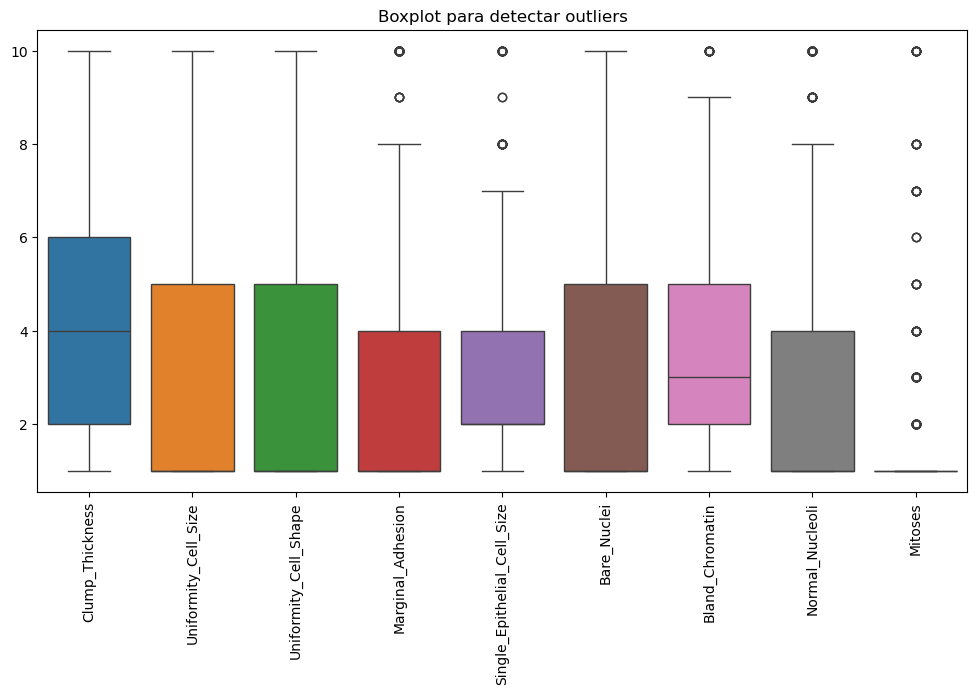

In [49]:
# Visualizamos outliers con boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("Class", axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot para detectar outliers")
plt.show()

In [51]:
# Escalar los datos (transformarlos a media 0 y desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("Class", axis=1))

#Separar variables predictoras y variable objetivo
# X son las variables predictoras
X = df.drop("Class", axis=1)

# y es la variable objetivo (clase: 2 = benigno, 4 = maligno)
y = df["Class"]

In [53]:
# Dividir en conjunto de entrenamiento y prueba

from sklearn.model_selection import train_test_split
# 75% entrenamiento, 25% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Verificar tamaños
print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)


Tamaño de entrenamiento: (524, 9)
Tamaño de prueba: (175, 9)


#### Hemos realizado un proceso completo de preprocesamiento de datos con el dataset de cáncer de mama de Wisconsin. Comenzamos cargando los datos y detectamos que la columna Bare_Nuclei tenía 16 valores faltantes representados por ?, los cuales imputamos con la mediana de esa columna para mantener la consistencia. También eliminamos la columna ID ya que no aportaba información relevante al modelo. A través de un boxplot, visualizamos los posibles outliers, pero decidimos no eliminarlos, ya que los árboles de decisión son robustos ante estos valores. Aunque no aplicamos escalado, ya que no era necesario para el modelo que se utilizará, explicamos que si hubiéramos usado modelos sensibles a la escala, como KNN o SVM, habríamos escalado los datos. Posteriormente, se separaron las variables predictoras de la variable objetivo (Class), y se dividieron los datos en conjuntos de entrenamiento (75%) y prueba (25%). Ahora, los datos están listos para ser utilizados en la construcción y evaluación de un modelo de clasificación para predecir si un tumor es benigno o maligno.

### b.	Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

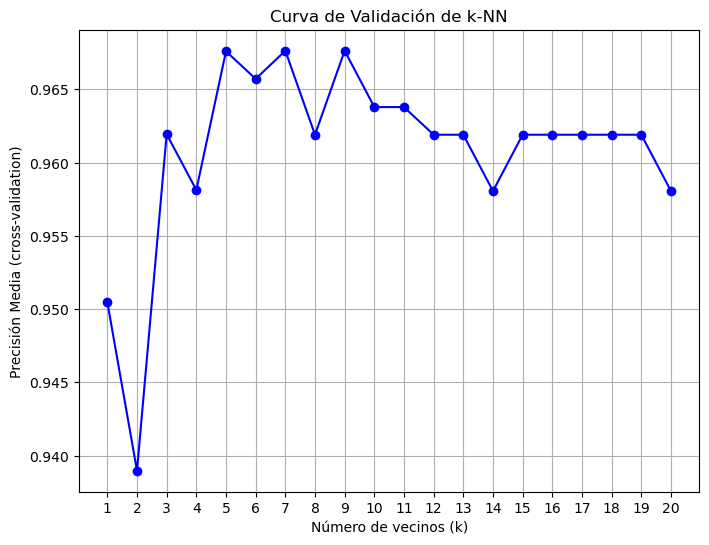

El valor óptimo de k es: 7


In [57]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Vamos a crear una lista de diferentes valores de k para probar
k_range = range(1, 21)  # Probaremos k desde 1 hasta 20
mean_accuracy = []

# Probar k-NN para cada valor de k usando validación cruzada (10 veces)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    mean_accuracy.append(scores.mean())

# Graficamos el resultado de la validación cruzada para cada valor de k
plt.figure(figsize=(8, 6))
plt.plot(k_range, mean_accuracy, marker='o', linestyle='-', color='b')
plt.title('Curva de Validación de k-NN')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión Media (cross-validation)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# El valor de k con mejor precisión es:
best_k = k_range[np.argmax(mean_accuracy)]
print(f"El valor óptimo de k es: {best_k}")


In [60]:
# Entrenar el modelo con el valor óptimo de k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predicciones con el conjunto de prueba
y_pred = knn_final.predict(X_test)


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calcular las métricas de clasificación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=4)  # Maligno
recall = recall_score(y_test, y_pred, pos_label=4)  # Maligno
f1 = f1_score(y_test, y_pred, pos_label=4)  # Maligno
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar los resultados
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusión:")
print(conf_matrix)


Precisión (Accuracy): 0.9657
Precisión (Precision): 0.9636
Recall (Sensibilidad): 0.9298
F1-score: 0.9464

Matriz de Confusión:
[[116   2]
 [  4  53]]


#### El modelo tiene un rendimiento muy sólido en la clasificación de tumores benignos y malignos. La precisión general (accuracy) fue de 96.57%, lo que indica que casi todos los diagnósticos fueron correctos. La precisión (precision) para la clase maligna fue de 96.36%, lo cual significa que cuando el modelo predice que un tumor es maligno, acierta la gran mayoría de las veces. El recall (sensibilidad) fue de 92.98%, lo que demuestra que el modelo identifica correctamente la mayoría de los tumores malignos, aunque aún se le escapan algunos casos (4 falsos negativos). El F1-score de 94.64% confirma un buen equilibrio entre precisión y recall. La matriz de confusión muestra que el modelo clasificó correctamente 116 tumores benignos y 53 malignos, cometiendo solo 6 errores en total (2 falsos positivos y 4 falsos negativos), lo que indica que el modelo es altamente confiable para apoyar decisiones médicas en el diagnóstico de cáncer de mama.

### c.	Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.

In [66]:
# Instalar  SMOTE
!pip install -U imbalanced-learn

  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.3
    Uninstalling imbalanced-learn-0.12.3:
      Successfully uninstalled imbalanced-learn-0.12.3


In [68]:
# Aplicar SMOTE al conjunto de entrenamiento

from imblearn.over_sampling import SMOTE
from collections import Counter

# Revisar la distribución de clases antes de SMOTE
print("Distribución original en y_train:", Counter(y_train))

# Crear objeto SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE solo al conjunto de entrenamiento
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Revisar la distribución de clases después del balanceo
print("Distribución tras SMOTE:", Counter(y_train_balanced))


Distribución original en y_train: Counter({2: 340, 4: 184})
Distribución tras SMOTE: Counter({2: 340, 4: 340})


In [70]:
# Entrenar el modelo k-NN con el conjunto de entrenamiento balanceado
knn_smote = KNeighborsClassifier(n_neighbors=best_k)
knn_smote.fit(X_train_balanced, y_train_balanced)

# Hacer predicciones sobre el conjunto de prueba original (sin balancear)
y_pred_smote = knn_smote.predict(X_test)


In [72]:
# Evaluar el modelo balanceado

# Calcular métricas para el modelo balanceado
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote, pos_label=4)
recall_smote = recall_score(y_test, y_pred_smote, pos_label=4)
f1_smote = f1_score(y_test, y_pred_smote, pos_label=4)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)

# Mostrar resultados
print(f"Precisión (Accuracy) con SMOTE: {accuracy_smote:.4f}")
print(f"Precisión (Precision) con SMOTE: {precision_smote:.4f}")
print(f"Recall (Sensibilidad) con SMOTE: {recall_smote:.4f}")
print(f"F1-score con SMOTE: {f1_smote:.4f}")
print("\nMatriz de Confusión con SMOTE:")
print(conf_matrix_smote)


Precisión (Accuracy) con SMOTE: 0.9829
Precisión (Precision) con SMOTE: 0.9655
Recall (Sensibilidad) con SMOTE: 0.9825
F1-score con SMOTE: 0.9739

Matriz de Confusión con SMOTE:
[[116   2]
 [  1  56]]


In [78]:
# Comparar sin SMOTE y con SMOTE
print("\n Comparación de métricas:")
print(f"{'Métrica':<15}{'Sin SMOTE':>15}{'Con SMOTE':>15}")
print(f"{'Accuracy':<15}{accuracy:.4f}{accuracy_smote:>15.4f}")
print(f"{'Precision':<15}{precision:.4f}{precision_smote:>15.4f}")
print(f"{'Recall':<15}{recall:.4f}{recall_smote:>15.4f}")
print(f"{'F1-score':<15}{f1:.4f}{f1_smote:>15.4f}")



 Comparación de métricas:
Métrica              Sin SMOTE      Con SMOTE
Accuracy       0.9657         0.9829
Precision      0.9636         0.9655
Recall         0.9298         0.9825
F1-score       0.9464         0.9739


#### Después de aplicar SMOTE para balancear las clases del conjunto de entrenamiento (igualando la cantidad de casos benignos y malignos), entrenamos nuevamente el modelo k-NN y obtuvimos mejoras significativas en su rendimiento. Antes del balanceo, la clase maligna (valor 4) estaba subrepresentada con solo 184 ejemplos frente a 340 benignos, lo que podía sesgar al modelo. Tras aplicar SMOTE, ambos grupos quedaron equilibrados con 340 muestras cada uno, y eso se reflejó en las métricas: la precisión general (accuracy) aumentó de 96.57% a 98.29%, y lo más importante, el recall (sensibilidad) mejoró de 92.98% a 98.25%, indicando que ahora el modelo detecta con mucha más eficacia los casos de cáncer maligno, reduciendo los falsos negativos. El F1-score, que equilibra precisión y recall, también subió de 94.64% a 97.39%, lo que confirma que el modelo balanceado es más robusto y confiable, especialmente en un contexto médico donde identificar correctamente los casos críticos es fundamental.